In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/csv/cleaned_dataset.csv', low_memory=False)
print(f"✓ Yüklendi: {df.shape[0]:,} satır, {df.shape[1]} sütun")

✓ Yüklendi: 1,100,025 satır, 72 sütun


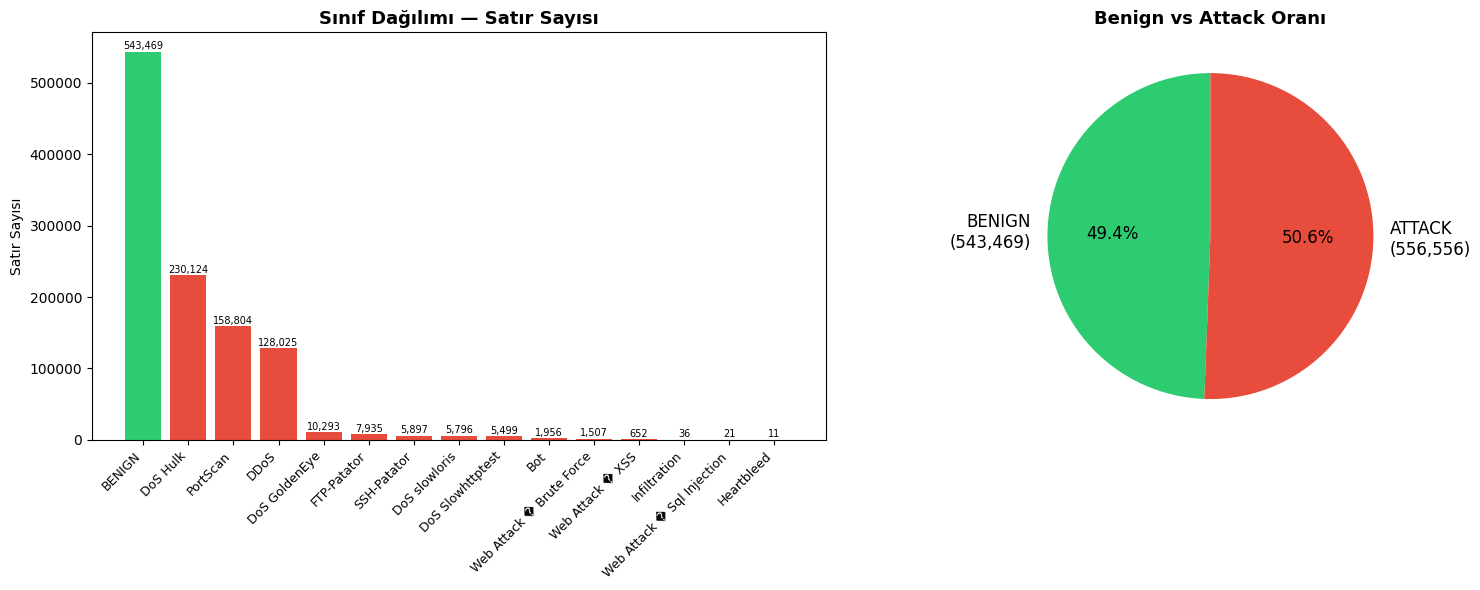

✓ Kaydedildi: plots_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts = df['Label'].value_counts()

# Sol: Bar chart
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in label_counts.index]
bars = axes[0].bar(range(len(label_counts)), label_counts.values, color=colors)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Sınıf Dağılımı — Satır Sayısı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Satır Sayısı')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=7)

# Sağ: Pie chart (Benign vs Attack toplam)
benign_total = label_counts['BENIGN']
attack_total = label_counts.drop('BENIGN').sum()
axes[1].pie([benign_total, attack_total],
            labels=[f'BENIGN\n({benign_total:,})', f'ATTACK\n({attack_total:,})'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Benign vs Attack Oranı', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plots_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Kaydedildi: plots_class_distribution.png")

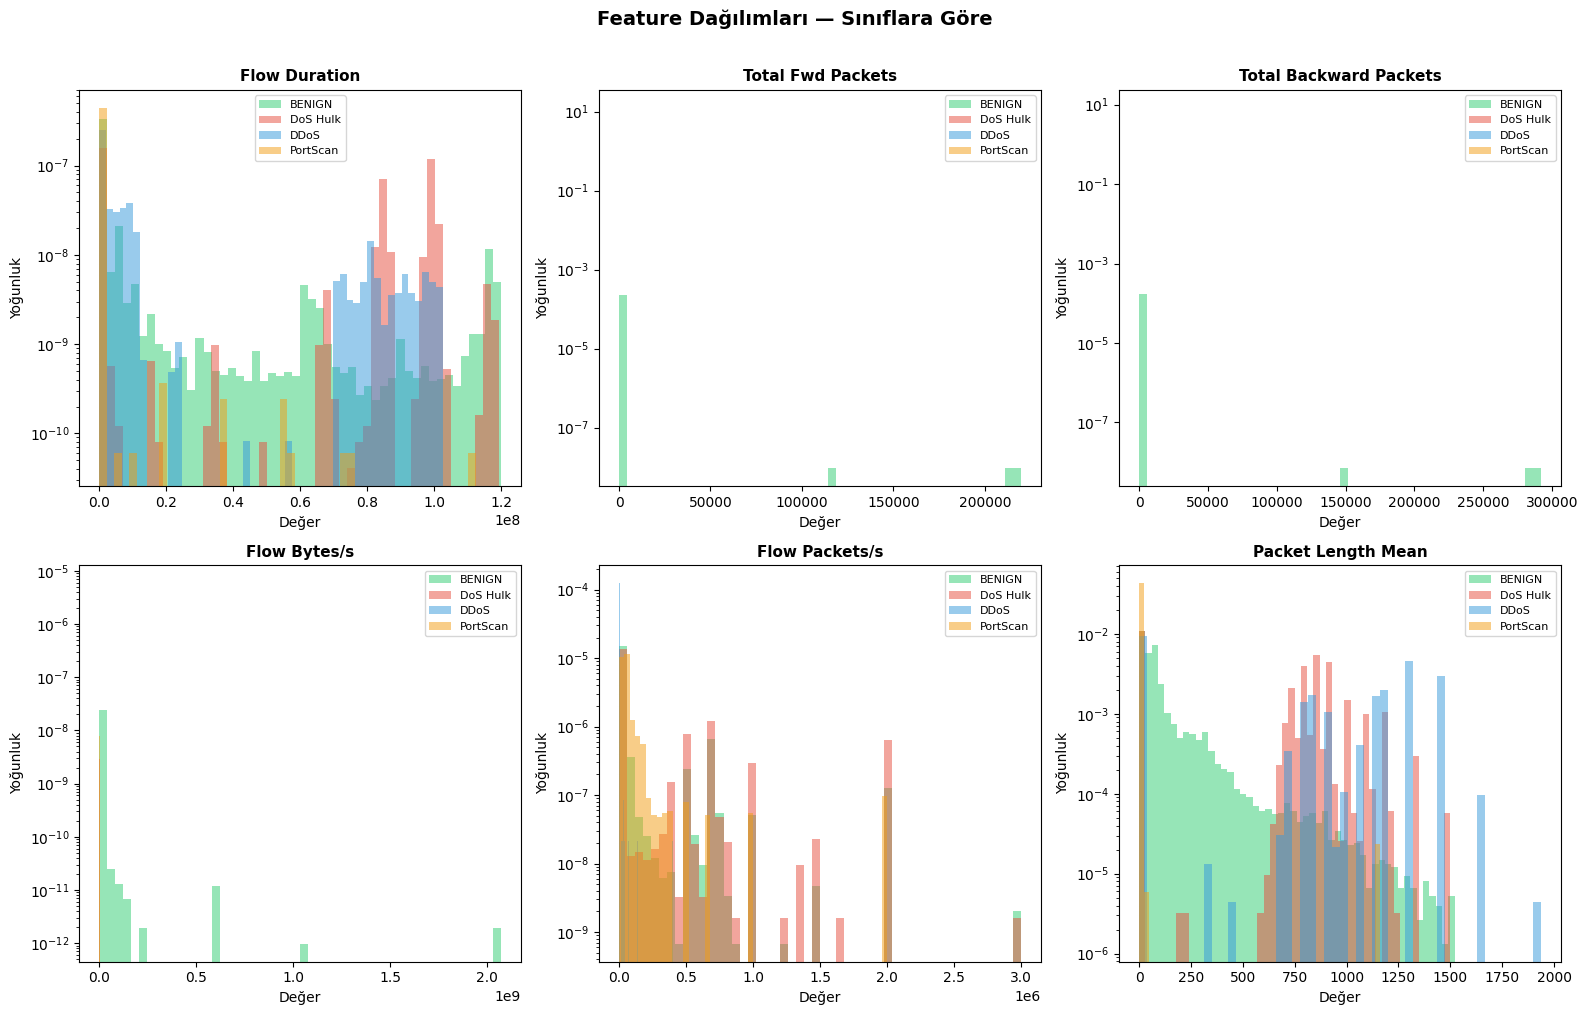

✓ Kaydedildi: plots_feature_distributions.png


In [7]:
# Sample al — görselleştirme için 50k yeterli
df_sample = df.sample(n=50000, random_state=42)

top_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color in [('BENIGN', '#2ecc71'), ('DoS Hulk', '#e74c3c'), 
                          ('DDoS', '#3498db'), ('PortScan', '#f39c12')]:
        subset = df_sample[df_sample['Label'] == label][feat]
        axes[i].hist(subset, bins=50, alpha=0.5, label=label, 
                     color=color, density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Yoğunluk')
    axes[i].legend(fontsize=8)
    axes[i].set_yscale('log')

plt.suptitle('Feature Dağılımları — Sınıflara Göre', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/plots_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Kaydedildi: plots_feature_distributions.png")

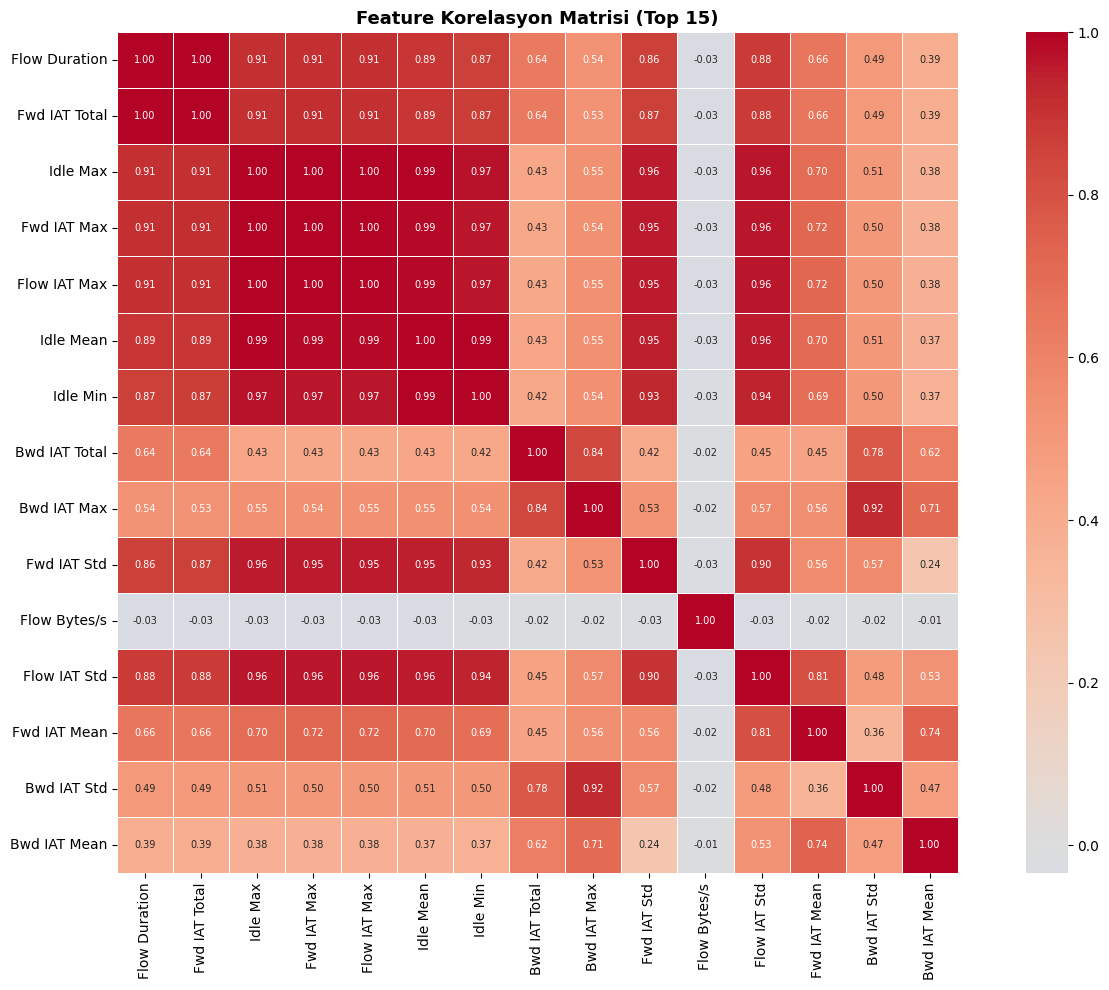

✓ Kaydedildi: plots_correlation_heatmap.png


In [8]:
df_sample = df.sample(n=10000, random_state=42)
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()

# En yüksek varyansa sahip 15 feature
top15 = df_sample[numeric_cols].var().nlargest(15).index.tolist()

corr = df_sample[top15].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Korelasyon Matrisi (Top 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Kaydedildi: plots_correlation_heatmap.png")